In [1]:
# Mount Google Drive so Colab can access your files
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [8]:
import os

ZIP_PATH = '/content/drive/MyDrive/AI ML /fruits_20_clean.zip'

print(os.path.exists(ZIP_PATH))

True


In [10]:
import zipfile

EXTRACT_PATH = '/content/fruits_dataset'

with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_PATH)

print("Extraction complete")

Extraction complete


In [11]:
print(os.listdir(EXTRACT_PATH))

['Test', 'Training']


In [14]:
TRAIN_DIR = '/content/fruits_dataset/Training'
TEST_DIR = '/content/fruits_dataset/Test'

In [15]:
import os

print('Train folder exists:', os.path.exists(TRAIN_DIR))
print('Test folder exists:', os.path.exists(TEST_DIR))

print('\nClasses found:')
print(os.listdir(TRAIN_DIR))

Train folder exists: True
Test folder exists: True

Classes found:
['Avocado 1', 'Strawberry 1', 'Peach 1', 'Apple Granny Smith 1', 'Mango 1', 'Lemon 1', 'Apple Red 1', 'Pomegranate 1', 'Cocos 1', 'Kiwi 1', 'Pineapple 1', 'Raspberry 1', 'Cherry 1', 'Orange 1', 'Grape Blue 1', 'Papaya 1', 'Blueberry 1', 'Watermelon 1', 'Pear 1', 'Banana 1']


In [17]:
# Basic libraries
import numpy as np               # for number operations
import matplotlib.pyplot as plt  # for plotting graphs
import seaborn as sns            # for confusion matrix
import os                        # for folder operations
import time                      # for measuring training time
import warnings
warnings.filterwarnings('ignore')

# For evaluation metrics
from sklearn.metrics import classification_report, confusion_matrix

# Keras / TensorFlow — our deep learning framework
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications import MobileNetV2

# Check GPU
print('TensorFlow version:', tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print('GPU available:', gpus)
else:
    print('No GPU — go to Runtime > Change runtime type > select GPU')

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Step 2A — Set Class Names & Count Images


In [18]:
# ============================================================
# STEP 2A — Get class names and count images per class
# ============================================================

# Get class names from folder names inside Train
CLASS_NAMES = sorted(os.listdir(TRAIN_DIR))
NUM_CLASSES = len(CLASS_NAMES)

print(f'Number of classes: {NUM_CLASSES}')
print(f'Class names: {CLASS_NAMES}')

# Count images in each class for Train and Test
def count_images(directory):
    counts = {}
    for cls in CLASS_NAMES:
        cls_path = os.path.join(directory, cls)
        if os.path.exists(cls_path):
            # only count image files
            images = [f for f in os.listdir(cls_path)
                      if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
            counts[cls] = len(images)
    return counts

train_counts = count_images(TRAIN_DIR)
test_counts  = count_images(TEST_DIR)

print('\n--- Training Set ---')
for cls, cnt in train_counts.items():
    print(f'  {cls}: {cnt} images')
print(f'  TOTAL: {sum(train_counts.values())} images')

print('\n--- Test Set ---')
for cls, cnt in test_counts.items():
    print(f'  {cls}: {cnt} images')
print(f'  TOTAL: {sum(test_counts.values())} images')

Number of classes: 20
Class names: ['Apple Granny Smith 1', 'Apple Red 1', 'Avocado 1', 'Banana 1', 'Blueberry 1', 'Cherry 1', 'Cocos 1', 'Grape Blue 1', 'Kiwi 1', 'Lemon 1', 'Mango 1', 'Orange 1', 'Papaya 1', 'Peach 1', 'Pear 1', 'Pineapple 1', 'Pomegranate 1', 'Raspberry 1', 'Strawberry 1', 'Watermelon 1']

--- Training Set ---
  Apple Granny Smith 1: 492 images
  Apple Red 1: 492 images
  Avocado 1: 427 images
  Banana 1: 490 images
  Blueberry 1: 462 images
  Cherry 1: 492 images
  Cocos 1: 490 images
  Grape Blue 1: 984 images
  Kiwi 1: 466 images
  Lemon 1: 492 images
  Mango 1: 490 images
  Orange 1: 479 images
  Papaya 1: 492 images
  Peach 1: 492 images
  Pear 1: 492 images
  Pineapple 1: 490 images
  Pomegranate 1: 492 images
  Raspberry 1: 490 images
  Strawberry 1: 492 images
  Watermelon 1: 475 images
  TOTAL: 10171 images

--- Test Set ---
  Apple Granny Smith 1: 164 images
  Apple Red 1: 164 images
  Avocado 1: 143 images
  Banana 1: 166 images
  Blueberry 1: 154 images


Step 2B — Plot Class Distribution

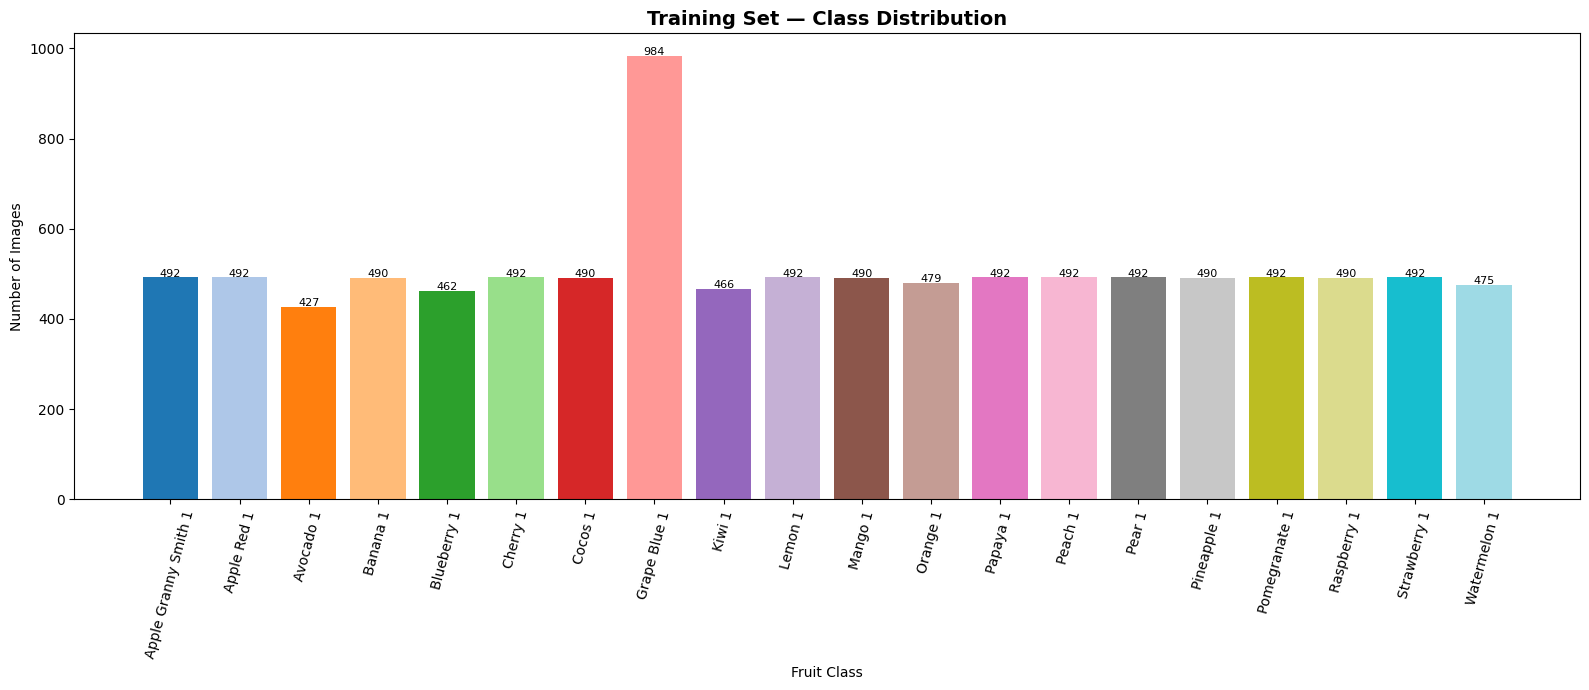

In [22]:
import matplotlib.pyplot as plt

colors = plt.cm.tab20.colors

fig, ax = plt.subplots(figsize=(16, 7))

bars = ax.bar(
    train_counts.keys(),
    train_counts.values(),
    color=colors[:len(train_counts)]
)

ax.set_title('Training Set — Class Distribution',
             fontsize=14,
             fontweight='bold')

ax.set_xlabel('Fruit Class')
ax.set_ylabel('Number of Images')

for bar, val in zip(bars, train_counts.values()):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 2,
        str(val),
        ha='center',
        fontsize=8
    )

plt.xticks(rotation=75)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()

Step 2C — Show Sample Images

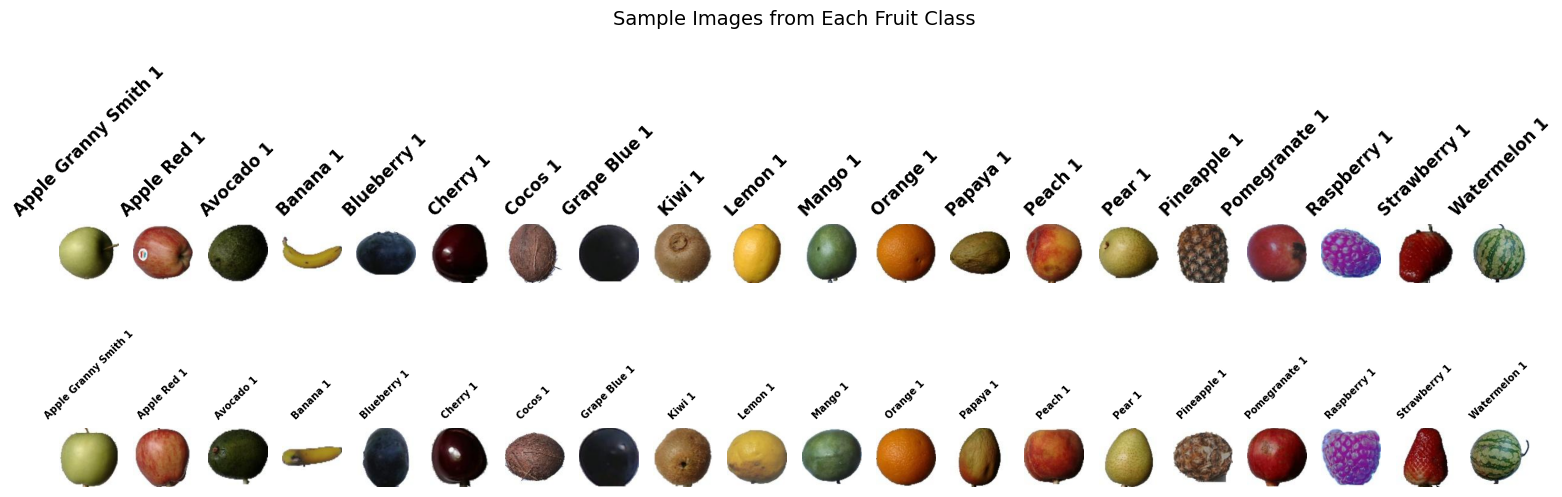

In [61]:
# ============================================================
# STEP 2C — Display 2 sample images from each fruit class
# ============================================================

fig, axes = plt.subplots(2, NUM_CLASSES, figsize=(15, 6))

for col, cls in enumerate(CLASS_NAMES):
    cls_path = os.path.join(TRAIN_DIR, cls)
    images_in_class = os.listdir(cls_path)

    for row in range(2):   # show 2 samples per class
        img_path = os.path.join(cls_path, images_in_class[row])
        img = plt.imread(img_path)
        axes[row, col].imshow(img)
        axes[row, col].axis('off')
        axes[row, col].set_title(cls, fontsize=7, fontweight='bold', rotation=45)
        if row == 0:
            axes[row, col].set_title(cls, fontsize=12,
                                     fontweight='bold')

plt.suptitle('Sample Images from Each Fruit Class', fontsize=14)
plt.tight_layout()
plt.savefig('sample_images.png', dpi=150)
plt.show()

In [24]:
# ============================================================
# STEP 2D — Count test images (no subfolders)
# ============================================================

test_images = [f for f in os.listdir(TEST_DIR)
               if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

print(f'Total test images: {len(test_images)}')
print('Sample test filenames:', test_images[:5])
print('\nNote: Test set has no class labels.')
print('We will use it only for final predictions.')

Total test images: 0
Sample test filenames: []

Note: Test set has no class labels.
We will use it only for final predictions.


Step 3A — Set Global Settings

In [25]:
# ============================================================
# STEP 3A — Global settings used throughout the whole project
# ============================================================

IMG_SIZE   = (128, 128)  # resize all images to 128x128 pixels
BATCH_SIZE = 32          # number of images processed at once
SEED       = 42          # keeps results reproducible

print('Settings:')
print(f'  Image size : {IMG_SIZE}')
print(f'  Batch size : {BATCH_SIZE}')
print(f'  Num classes: {NUM_CLASSES}')

Settings:
  Image size : (128, 128)
  Batch size : 32
  Num classes: 20


Step 3B — Create Data Generators

In [27]:
# Recreate generators after removing corrupted files
train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

val_datagen = ImageDataGenerator(
    rescale=1.0/255,
    validation_split=0.2
)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=SEED
)

val_gen = val_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=SEED
)

print(' Generators recreated!')
print(f'Training batches  : {len(train_gen)}')
print(f'Validation batches: {len(val_gen)}')

Found 8143 images belonging to 20 classes.
Found 2028 images belonging to 20 classes.
 Generators recreated!
Training batches  : 255
Validation batches: 64


Step 3C — Visualize Augmented Images

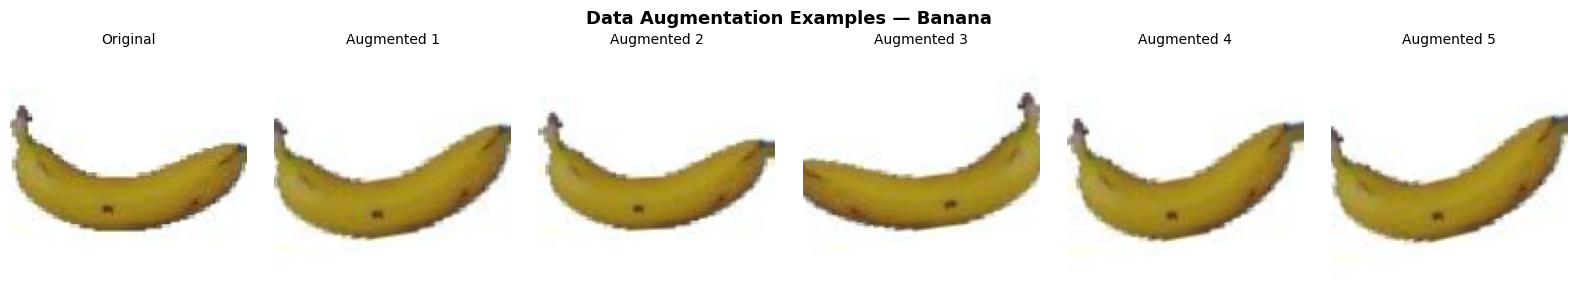

Augmentation is working correctly!
Each augmented image looks slightly different from the original.
This helps the model learn better and prevents overfitting.


In [29]:
# ============================================================
# STEP 3C — Show what augmented images look like
# This confirms augmentation is working correctly
# ============================================================

# Create a small augmentation generator just for visualization
aug_datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True
)

# Pick one sample image from Banana class
# Fixed: Changed 'Banana' to 'Banana 1' as per actual class name
sample_dir  = os.path.join(TRAIN_DIR, 'Banana 1')
sample_file = os.listdir(sample_dir)[0]
sample_path = os.path.join(sample_dir, sample_file)

# Load and prepare image for generator
img = tf.keras.preprocessing.image.load_img(
    sample_path, target_size=IMG_SIZE)
img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)  # add batch dimension

# Generate augmented versions
aug_iter = aug_datagen.flow(img_array, batch_size=1)

# Plot original + 5 augmented versions
fig, axes = plt.subplots(1, 6, figsize=(16, 3))

# Show original
axes[0].imshow(img_array[0] / 255.0)
axes[0].set_title('Original', fontsize=10)
axes[0].axis('off')

# Show 5 augmented
for i in range(1, 6):
    aug_img = next(aug_iter)[0]
    axes[i].imshow(aug_img)
    axes[i].set_title(f'Augmented {i}', fontsize=10)
    axes[i].axis('off')

plt.suptitle('Data Augmentation Examples — Banana',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('augmentation_examples.png', dpi=150)
plt.show()

print('Augmentation is working correctly!')
print('Each augmented image looks slightly different from the original.')
print('This helps the model learn better and prevents overfitting.')

Step 4A — Build the Baseline CNN

In [30]:
# ============================================================
# STEP 4A — Build Baseline CNN Model
#
# Architecture:
# - 3 Convolutional blocks (Conv2D + MaxPooling)
# - 3 Fully Connected (Dense) layers
# - 1 Output layer with Softmax
#
# WHY this architecture?
# Conv layers extract features (edges, colors, shapes)
# MaxPooling reduces image size keeping important features
# Dense layers learn to classify based on those features
# Softmax outputs probability for each of 5 fruit classes
# ============================================================

def build_baseline_cnn(num_classes, input_shape=(128, 128, 3)):

    model = models.Sequential(name='Baseline_CNN')

    # --- Conv Block 1 ---
    # 32 filters learn basic features like edges and colors
    model.add(layers.Conv2D(32, (3, 3), activation='relu',
                            padding='same',
                            input_shape=input_shape))
    model.add(layers.MaxPooling2D((2, 2)))  # 128x128 → 64x64

    # --- Conv Block 2 ---
    # 64 filters learn more complex features like shapes
    model.add(layers.Conv2D(64, (3, 3), activation='relu',
                            padding='same'))
    model.add(layers.MaxPooling2D((2, 2)))  # 64x64 → 32x32

    # --- Conv Block 3 ---
    # 128 filters learn high level features like textures
    model.add(layers.Conv2D(128, (3, 3), activation='relu',
                            padding='same'))
    model.add(layers.MaxPooling2D((2, 2)))  # 32x32 → 16x16

    # --- Flatten ---
    # Convert 3D feature maps into 1D vector
    model.add(layers.Flatten())

    # --- Fully Connected Layers ---
    model.add(layers.Dense(256, activation='relu'))  # FCN 1
    model.add(layers.Dense(128, activation='relu'))  # FCN 2
    model.add(layers.Dense(64,  activation='relu'))  # FCN 3

    # --- Output Layer ---
    # 5 neurons = 5 fruit classes, softmax gives probability
    model.add(layers.Dense(num_classes, activation='softmax'))

    return model


# Create the model
baseline_model = build_baseline_cnn(NUM_CLASSES)

# Print model summary
baseline_model.summary()


Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 20)             │         1,300 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,524,564 (32.52 MB)

 Trainable params: 8,524,564 (32.52 MB)

 Non-trainable params: 0 (0.00 B)

Step 4B — Compile the Baseline Model

In [32]:
# ============================================================
# STEP 4B — Compile the baseline model
#
# optimizer = Adam (automatically adjusts learning rate)
# loss = categorical_crossentropy (standard for multi-class)
# metrics = accuracy (how many images classified correctly)
# ============================================================

baseline_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print('Baseline model compiled successfully!')
print('\nOptimizer : Adam')
print('Loss      : Categorical Crossentropy')
print('Metric    : Accuracy')

Baseline model compiled successfully!

Optimizer : Adam
Loss      : Categorical Crossentropy
Metric    : Accuracy


Step 4C — Train the Baseline Model

In [33]:
# Reset the model completely before retraining
baseline_model = build_baseline_cnn(NUM_CLASSES)
baseline_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_baseline = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        verbose=1
    )
]

print('Retraining Baseline CNN after removing corrupted files...\n')
start_time = time.time()

history_baseline = baseline_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=25,
    callbacks=callbacks_baseline,
    verbose=1
)

baseline_train_time = time.time() - start_time
print(f'\n Training done!')
print(f'Training time: {baseline_train_time:.1f} seconds')

Retraining Baseline CNN after removing corrupted files...

Epoch 1/25
255/255 ━━━━━━━━━━━━━━━━━━━━ 51s 173ms/step - accuracy: 0.7300 - loss: 0.8124 - val_accuracy: 0.9734 - val_loss: 0.0793 - learning_rate: 0.0010
Epoch 2/25
255/255 ━━━━━━━━━━━━━━━━━━━━ 40s 158ms/step - accuracy: 0.9718 - loss: 0.0837 - val_accuracy: 1.0000 - val_loss: 0.0051 - learning_rate: 0.0010
Epoch 3/25
255/255 ━━━━━━━━━━━━━━━━━━━━ 40s 156ms/step - accuracy: 0.9761 - loss: 0.0754 - val_accuracy: 0.9951 - val_loss: 0.0188 - learning_rate: 0.0010
Epoch 4/25
255/255 ━━━━━━━━━━━━━━━━━━━━ 40s 156ms/step - accuracy: 0.9842 - loss: 0.0569 - val_accuracy: 1.0000 - val_loss: 0.0037 - learning_rate: 0.0010
Epoch 5/25
255/255 ━━━━━━━━━━━━━━━━━━━━ 40s 155ms/step - accuracy: 0.9797 - loss: 0.0624 - val_accuracy: 0.9887 - val_loss: 0.0273 - learning_rate: 0.0010
Epoch 6/25
255/255 ━━━━━━━━━━━━━━━━━━━━ 38s 149ms/step - accuracy: 0.9881 - loss: 0.0369 - val_accuracy: 0.9980 - val_loss: 0.0125 - learning_rate: 0.0010
Epoch 7/25


In [34]:
# ============================================================
# FIX — Find and remove corrupted/unreadable images
# The error means some files cannot be opened as images
# ============================================================

from PIL import Image

corrupted = []

for cls in CLASS_NAMES:
    cls_path = os.path.join(TRAIN_DIR, cls)
    for fname in os.listdir(cls_path):
        fpath = os.path.join(cls_path, fname)
        try:
            # Try to open each image
            img = Image.open(fpath)
            img.verify()  # verify it is a real image
        except Exception as e:
            print(f' Corrupted: {fpath}')
            corrupted.append(fpath)

print(f'\nTotal corrupted files found: {len(corrupted)}')


Total corrupted files found: 0


Corrupted file remove

In [36]:
# ============================================================
# Delete all corrupted files found above
# ============================================================

import os

for fpath in corrupted:
    os.remove(fpath)
    print(f' Deleted: {fpath}')

print(f'\n Deleted {len(corrupted)} corrupted files!')
print('Now re-run Step 3B to recreate the generators')


 Deleted 0 corrupted files!
Now re-run Step 3B to recreate the generators


In [37]:
# Recreate generators after removing corrupted files
train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

val_datagen = ImageDataGenerator(
    rescale=1.0/255,
    validation_split=0.2
)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=SEED
)

val_gen = val_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=SEED
)

print('Generators recreated!')
print(f'Training batches  : {len(train_gen)}')
print(f'Validation batches: {len(val_gen)}')

Found 8143 images belonging to 20 classes.
Found 2028 images belonging to 20 classes.
Generators recreated!
Training batches  : 255
Validation batches: 64


Step 4D — Plot Training Results

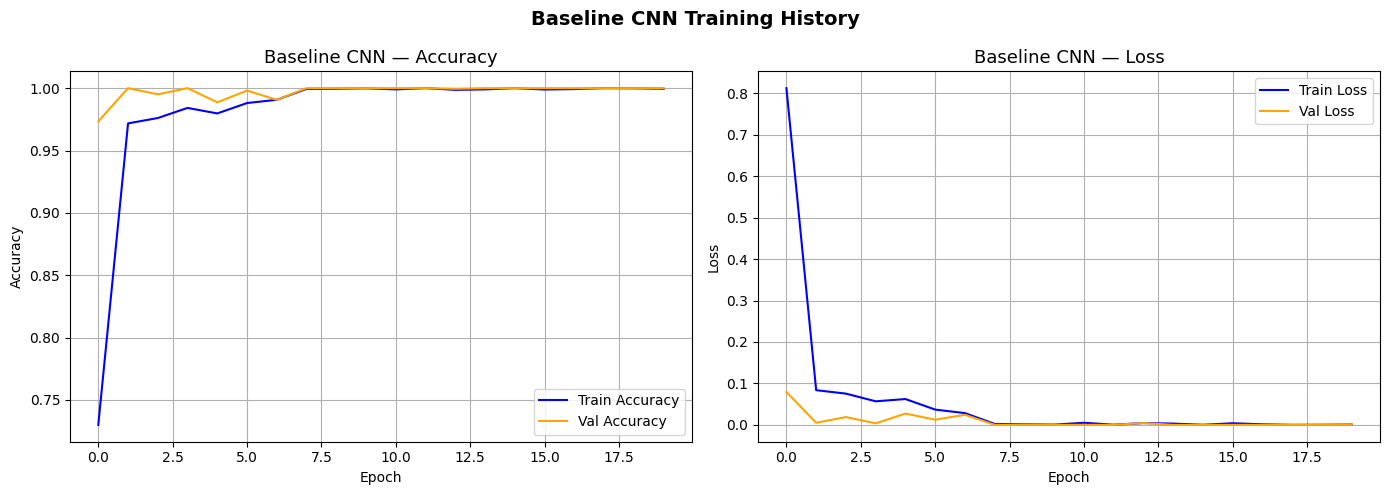

Final Train Accuracy     : 99.95%
Final Validation Accuracy: 100.00%


In [38]:
# ============================================================
# STEP 4D — Plot accuracy and loss curves
#
# If train accuracy >> val accuracy = OVERFITTING
# If both are low = UNDERFITTING
# If both are close and high = GOOD model
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Accuracy plot ---
axes[0].plot(history_baseline.history['accuracy'],
             label='Train Accuracy', color='blue')
axes[0].plot(history_baseline.history['val_accuracy'],
             label='Val Accuracy', color='orange')
axes[0].set_title('Baseline CNN — Accuracy', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# --- Loss plot ---
axes[1].plot(history_baseline.history['loss'],
             label='Train Loss', color='blue')
axes[1].plot(history_baseline.history['val_loss'],
             label='Val Loss', color='orange')
axes[1].set_title('Baseline CNN — Loss', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('Baseline CNN Training History',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('baseline_history.png', dpi=150)
plt.show()

# Print final accuracy
final_train_acc = history_baseline.history['accuracy'][-1]
final_val_acc   = history_baseline.history['val_accuracy'][-1]
print(f'Final Train Accuracy     : {final_train_acc*100:.2f}%')
print(f'Final Validation Accuracy: {final_val_acc*100:.2f}%')

Step 4E — Evaluate the Baseline Model

64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step

 Baseline CNN — Test Accuracy: 100.00%

Classification Report:
                      precision    recall  f1-score   support

Apple Granny Smith 1       1.00      1.00      1.00        98
         Apple Red 1       1.00      1.00      1.00        98
           Avocado 1       1.00      1.00      1.00        85
            Banana 1       1.00      1.00      1.00        98
         Blueberry 1       1.00      1.00      1.00        92
            Cherry 1       1.00      1.00      1.00        98
             Cocos 1       1.00      1.00      1.00        98
        Grape Blue 1       1.00      1.00      1.00       196
              Kiwi 1       1.00      1.00      1.00        93
             Lemon 1       1.00      1.00      1.00        98
             Mango 1       1.00      1.00      1.00        98
            Orange 1       1.00      1.00      1.00        95
            Papaya 1       1.00      1.00      1.00        98
             Peach 1       

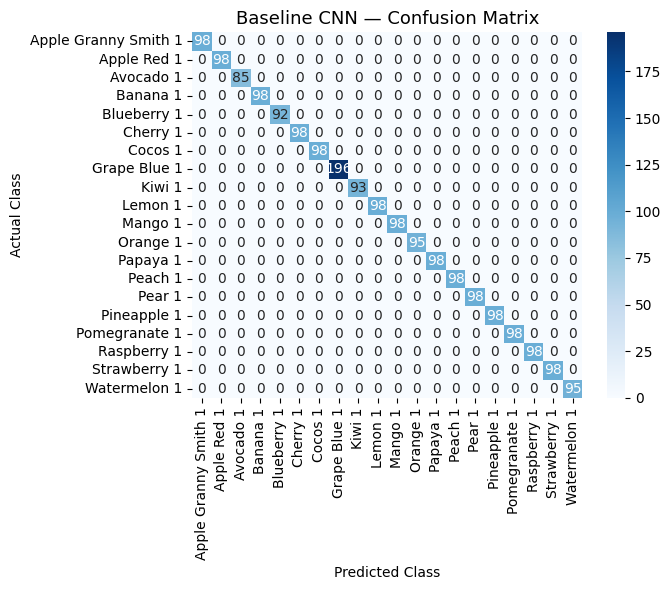


Baseline accuracy saved: 100.00%
Training time saved    : 868.2s


In [39]:
# ============================================================
# STEP 4E — Evaluate model with metrics + confusion matrix
# ============================================================

# Get predictions on validation set
val_gen.reset()
y_pred_probs = baseline_model.predict(val_gen, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)  # predicted class
y_true = val_gen.classes                  # true class

# Overall accuracy
accuracy = np.sum(y_pred == y_true) / len(y_true)
print(f'\n Baseline CNN — Test Accuracy: {accuracy*100:.2f}%')

# Classification report (Precision, Recall, F1)
print('\nClassification Report:')
print(classification_report(y_true, y_pred,
                            target_names=CLASS_NAMES))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES)
plt.title('Baseline CNN — Confusion Matrix', fontsize=13)
plt.ylabel('Actual Class')
plt.xlabel('Predicted Class')
plt.tight_layout()
plt.savefig('baseline_confusion_matrix.png', dpi=150)
plt.show()

# Save accuracy for later comparison
baseline_acc = accuracy
print(f'\nBaseline accuracy saved: {baseline_acc*100:.2f}%')
print(f'Training time saved    : {baseline_train_time:.1f}s')

Step 5A — Build the Deeper CNN

In [40]:
# ============================================================
# STEP 5A — Build Deeper CNN Model
#
# Differences from Baseline:
# - 6 Conv layers instead of 3 (double the depth)
# - BatchNormalization after each Conv layer
#   → stabilizes training, makes it faster
# - Dropout after each block
#   → randomly turns off neurons to prevent overfitting
#
# WHY deeper?
# More layers = model can learn more complex patterns
# ============================================================

def build_deeper_cnn(num_classes, input_shape=(128, 128, 3)):

    model = models.Sequential(name='Deeper_CNN')

    # --- Block 1 (32 filters) ---
    model.add(layers.Conv2D(32, (3, 3), activation='relu',
                            padding='same',
                            input_shape=input_shape))
    model.add(layers.BatchNormalization())  # normalize outputs
    model.add(layers.Conv2D(32, (3, 3), activation='relu',
                            padding='same'))
    model.add(layers.MaxPooling2D((2, 2)))  # 128x128 → 64x64
    model.add(layers.Dropout(0.25))        # drop 25% of neurons

    # --- Block 2 (64 filters) ---
    model.add(layers.Conv2D(64, (3, 3), activation='relu',
                            padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(64, (3, 3), activation='relu',
                            padding='same'))
    model.add(layers.MaxPooling2D((2, 2)))  # 64x64 → 32x32
    model.add(layers.Dropout(0.25))

    # --- Block 3 (128 filters) ---
    model.add(layers.Conv2D(128, (3, 3), activation='relu',
                            padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(128, (3, 3), activation='relu',
                            padding='same'))
    model.add(layers.MaxPooling2D((2, 2)))  # 32x32 → 16x16
    model.add(layers.Dropout(0.25))

    # --- Flatten ---
    model.add(layers.Flatten())

    # --- Fully Connected Layers ---
    model.add(layers.Dense(512, activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.5))   # higher dropout in dense layers

    model.add(layers.Dense(256, activation='relu'))
    model.add(layers.Dropout(0.3))

    model.add(layers.Dense(128, activation='relu'))

    # --- Output Layer ---
    model.add(layers.Dense(num_classes, activation='softmax'))

    return model


# Create the deeper model
deeper_model = build_deeper_cnn(NUM_CLASSES)
deeper_model.summary()

Model: "Deeper_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 512)            │    16,777,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 20)             │         2,58

 Total params: 17,234,484 (65.74 MB)

 Trainable params: 17,233,012 (65.74 MB)

 Non-trainable params: 1,472 (5.75 KB)

Step 5B — Compile & Train the Deeper Model

In [41]:
# ============================================================
# STEP 5B — Compile and train the deeper model
# ============================================================

deeper_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_deeper = [
    EarlyStopping(
        monitor='val_loss',
        patience=6,               # slightly more patient than baseline
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        verbose=1
    )
]

print('Training Deeper CNN...')
print('This will take longer than baseline due to more layers...\n')
start_time = time.time()

history_deeper = deeper_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=30,
    callbacks=callbacks_deeper,
    verbose=1
)

deeper_train_time = time.time() - start_time
print(f'\n Deeper CNN training done!')
print(f'Training time: {deeper_train_time:.1f} seconds')

Training Deeper CNN...
This will take longer than baseline due to more layers...

Epoch 1/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 73s 219ms/step - accuracy: 0.7223 - loss: 0.8181 - val_accuracy: 0.1149 - val_loss: 7.0419 - learning_rate: 0.0010
Epoch 2/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 44s 171ms/step - accuracy: 0.9135 - loss: 0.2469 - val_accuracy: 0.6558 - val_loss: 1.8414 - learning_rate: 0.0010
Epoch 3/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 44s 173ms/step - accuracy: 0.9535 - loss: 0.1362 - val_accuracy: 0.7914 - val_loss: 0.4442 - learning_rate: 0.0010
Epoch 4/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 44s 173ms/step - accuracy: 0.9450 - loss: 0.1679 - val_accuracy: 0.9379 - val_loss: 0.1647 - learning_rate: 0.0010
Epoch 5/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 44s 172ms/step - accuracy: 0.9643 - loss: 0.1028 - val_accuracy: 0.9393 - val_loss: 0.1705 - learning_rate: 0.0010
Epoch 6/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 43s 167ms/step - accuracy: 0.9655 - loss: 0.1076 - val_accuracy: 0.8920 - val_loss: 0.4109 - learning_r

Step 5C — Plot Deeper Model Results

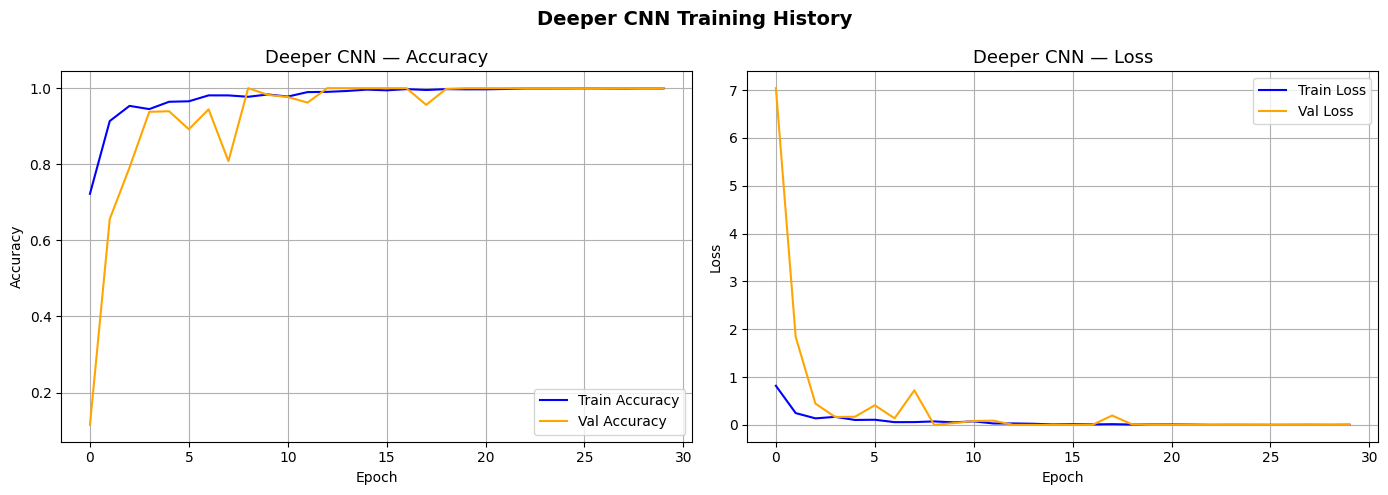

Final Train Accuracy     : 99.94%
Final Validation Accuracy: 100.00%


In [42]:
# ============================================================
# STEP 5C — Plot accuracy and loss for deeper model
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history_deeper.history['accuracy'],
             label='Train Accuracy', color='blue')
axes[0].plot(history_deeper.history['val_accuracy'],
             label='Val Accuracy', color='orange')
axes[0].set_title('Deeper CNN — Accuracy', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# Loss
axes[1].plot(history_deeper.history['loss'],
             label='Train Loss', color='blue')
axes[1].plot(history_deeper.history['val_loss'],
             label='Val Loss', color='orange')
axes[1].set_title('Deeper CNN — Loss', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('Deeper CNN Training History',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('deeper_history.png', dpi=150)
plt.show()

final_train_acc = history_deeper.history['accuracy'][-1]
final_val_acc   = history_deeper.history['val_accuracy'][-1]
print(f'Final Train Accuracy     : {final_train_acc*100:.2f}%')
print(f'Final Validation Accuracy: {final_val_acc*100:.2f}%')

Step 5D — Evaluate Deeper Model

64/64 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step

 Deeper CNN Accuracy: 100.00%

Classification Report:
                      precision    recall  f1-score   support

Apple Granny Smith 1       1.00      1.00      1.00        98
         Apple Red 1       1.00      1.00      1.00        98
           Avocado 1       1.00      1.00      1.00        85
            Banana 1       1.00      1.00      1.00        98
         Blueberry 1       1.00      1.00      1.00        92
            Cherry 1       1.00      1.00      1.00        98
             Cocos 1       1.00      1.00      1.00        98
        Grape Blue 1       1.00      1.00      1.00       196
              Kiwi 1       1.00      1.00      1.00        93
             Lemon 1       1.00      1.00      1.00        98
             Mango 1       1.00      1.00      1.00        98
            Orange 1       1.00      1.00      1.00        95
            Papaya 1       1.00      1.00      1.00        98
             Peach 1       1.00     

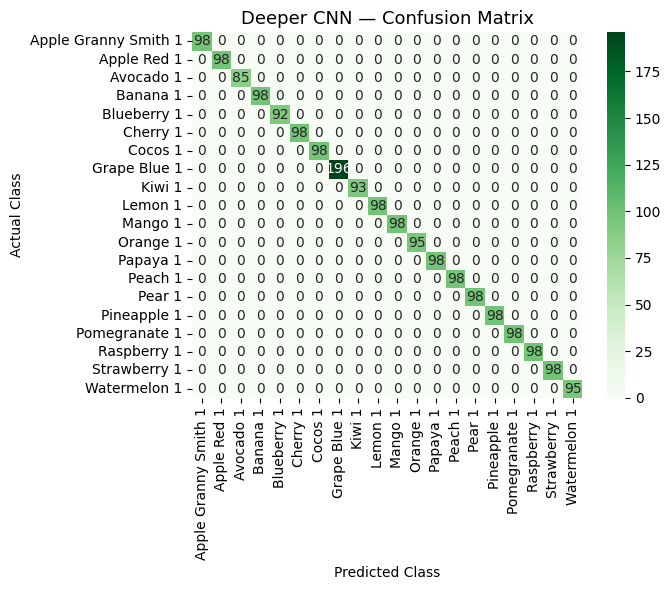

In [43]:
# ============================================================
# STEP 5D — Evaluate deeper model on validation set
# ============================================================

val_gen.reset()
y_pred_probs_deep = deeper_model.predict(val_gen, verbose=1)
y_pred_deep = np.argmax(y_pred_probs_deep, axis=1)
y_true_deep = val_gen.classes

# Accuracy
deeper_acc = np.sum(y_pred_deep == y_true_deep) / len(y_true_deep)
print(f'\n Deeper CNN Accuracy: {deeper_acc*100:.2f}%')

# Classification report
print('\nClassification Report:')
print(classification_report(y_true_deep, y_pred_deep,
                            target_names=CLASS_NAMES))

# Confusion matrix
cm_deep = confusion_matrix(y_true_deep, y_pred_deep)
plt.figure(figsize=(7, 6))
sns.heatmap(cm_deep, annot=True, fmt='d', cmap='Greens',
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES)
plt.title('Deeper CNN — Confusion Matrix', fontsize=13)
plt.ylabel('Actual Class')
plt.xlabel('Predicted Class')
plt.tight_layout()
plt.savefig('deeper_confusion_matrix.png', dpi=150)
plt.show()

Step 5E — Compare Baseline vs Deeper

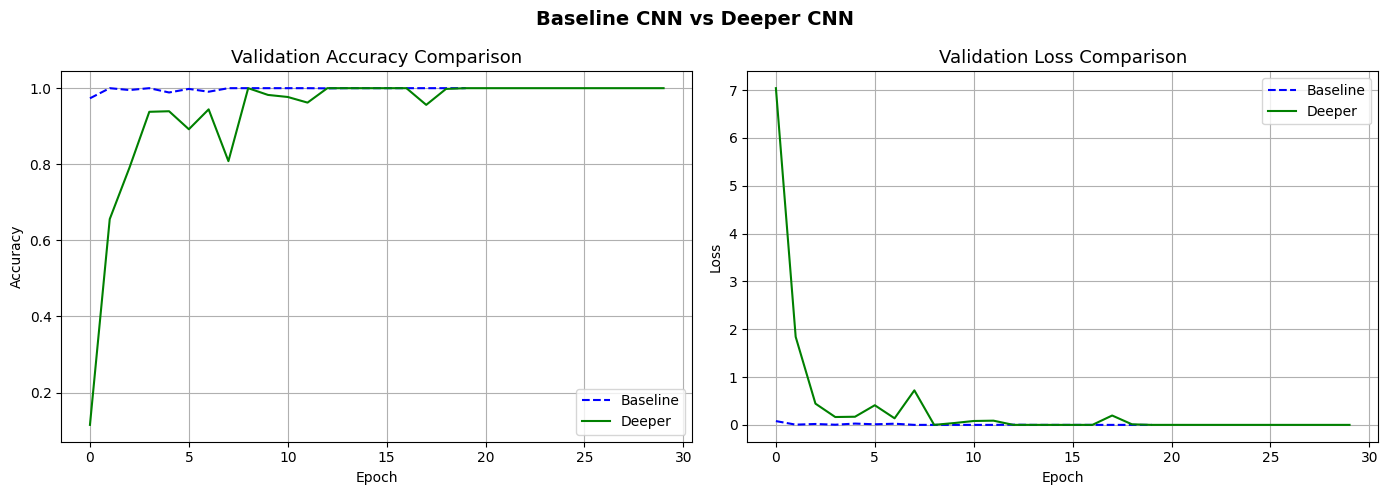

Model                       Accuracy      Train Time
Baseline CNN                 100.00%         868.2s
Deeper CNN                   100.00%        1328.7s

Baseline performed similarly — dataset may be simple enough.


In [44]:
# ============================================================
# STEP 5E — Compare both models side by side
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Validation Accuracy comparison
axes[0].plot(history_baseline.history['val_accuracy'],
             label='Baseline', color='blue', linestyle='--')
axes[0].plot(history_deeper.history['val_accuracy'],
             label='Deeper', color='green')
axes[0].set_title('Validation Accuracy Comparison', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# Validation Loss comparison
axes[1].plot(history_baseline.history['val_loss'],
             label='Baseline', color='blue', linestyle='--')
axes[1].plot(history_deeper.history['val_loss'],
             label='Deeper', color='green')
axes[1].set_title('Validation Loss Comparison', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('Baseline CNN vs Deeper CNN',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('baseline_vs_deeper.png', dpi=150)
plt.show()

# Print summary table
print('=' * 55)
print(f'{"Model":<20} {"Accuracy":>15} {"Train Time":>15}')
print('=' * 55)
print(f'{"Baseline CNN":<20} {baseline_acc*100:>14.2f}%'
      f' {baseline_train_time:>13.1f}s')
print(f'{"Deeper CNN":<20} {deeper_acc*100:>14.2f}%'
      f' {deeper_train_time:>13.1f}s')
print('=' * 55)

if deeper_acc > baseline_acc:
    diff = (deeper_acc - baseline_acc) * 100
    print(f'\n Deeper CNN improved accuracy by {diff:.2f}%')
    print('BatchNorm and Dropout helped reduce overfitting.')
else:
    print('\nBaseline performed similarly — dataset may be simple enough.')

Step 6A — Train Deeper CNN with SGD

In [45]:
# ============================================================
# STEP 6A — Train Deeper CNN with SGD optimizer
#
# SGD = Stochastic Gradient Descent
# - Updates weights using a fixed learning rate
# - Slower to converge but can generalize well
# - momentum=0.9 helps it not get stuck
# ============================================================

print('Training Deeper CNN with SGD optimizer...\n')

# Build a fresh model for SGD experiment
model_sgd = build_deeper_cnn(NUM_CLASSES)

model_sgd.compile(
    optimizer=tf.keras.optimizers.SGD(
        learning_rate=0.01,  # fixed learning rate
        momentum=0.9         # helps speed up learning
    ),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

start_time = time.time()

history_sgd = model_sgd.fit(
    train_gen,
    validation_data=val_gen,
    epochs=25,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=5,
                      restore_best_weights=True, verbose=1)
    ],
    verbose=1
)

sgd_time = time.time() - start_time
sgd_acc  = max(history_sgd.history['val_accuracy'])

print(f'\n SGD Training done!')
print(f'Best Validation Accuracy : {sgd_acc*100:.2f}%')
print(f'Training Time            : {sgd_time:.1f} seconds')

Training Deeper CNN with SGD optimizer...

Epoch 1/25
255/255 ━━━━━━━━━━━━━━━━━━━━ 61s 205ms/step - accuracy: 0.6256 - loss: 1.0785 - val_accuracy: 0.7988 - val_loss: 0.3606
Epoch 2/25
255/255 ━━━━━━━━━━━━━━━━━━━━ 43s 170ms/step - accuracy: 0.8421 - loss: 0.4338 - val_accuracy: 0.8082 - val_loss: 0.4401
Epoch 3/25
255/255 ━━━━━━━━━━━━━━━━━━━━ 43s 169ms/step - accuracy: 0.8908 - loss: 0.3270 - val_accuracy: 0.9009 - val_loss: 0.2337
Epoch 4/25
255/255 ━━━━━━━━━━━━━━━━━━━━ 43s 169ms/step - accuracy: 0.9242 - loss: 0.2219 - val_accuracy: 0.9389 - val_loss: 0.1337
Epoch 5/25
255/255 ━━━━━━━━━━━━━━━━━━━━ 44s 171ms/step - accuracy: 0.9435 - loss: 0.1659 - val_accuracy: 0.9896 - val_loss: 0.0359
Epoch 6/25
255/255 ━━━━━━━━━━━━━━━━━━━━ 43s 170ms/step - accuracy: 0.9510 - loss: 0.1407 - val_accuracy: 0.9768 - val_loss: 0.0625
Epoch 7/25
255/255 ━━━━━━━━━━━━━━━━━━━━ 43s 169ms/step - accuracy: 0.9557 - loss: 0.1288 - val_accuracy: 0.9734 - val_loss: 0.0649
Epoch 8/25
255/255 ━━━━━━━━━━━━━━━━━━━━ 

Step 6B — Train Deeper CNN with Adam

In [46]:
# ============================================================
# STEP 6B — Train Deeper CNN with Adam optimizer
#
# Adam = Adaptive Moment Estimation
# - Automatically adjusts learning rate for each parameter
# - Faster convergence than SGD
# - Works well in most deep learning tasks
# ============================================================

print('Training Deeper CNN with Adam optimizer...\n')

# Build a fresh model for Adam experiment
model_adam = build_deeper_cnn(NUM_CLASSES)

model_adam.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001  # default Adam learning rate
    ),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

start_time = time.time()

history_adam = model_adam.fit(
    train_gen,
    validation_data=val_gen,
    epochs=25,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=5,
                      restore_best_weights=True, verbose=1)
    ],
    verbose=1
)

adam_time = time.time() - start_time
adam_acc  = max(history_adam.history['val_accuracy'])

print(f'\n Adam Training done!')
print(f'Best Validation Accuracy : {adam_acc*100:.2f}%')
print(f'Training Time            : {adam_time:.1f} seconds')

Training Deeper CNN with Adam optimizer...

Epoch 1/25
255/255 ━━━━━━━━━━━━━━━━━━━━ 61s 200ms/step - accuracy: 0.7494 - loss: 0.7499 - val_accuracy: 0.2096 - val_loss: 8.8892
Epoch 2/25
255/255 ━━━━━━━━━━━━━━━━━━━━ 42s 163ms/step - accuracy: 0.9035 - loss: 0.2808 - val_accuracy: 0.7722 - val_loss: 0.7395
Epoch 3/25
255/255 ━━━━━━━━━━━━━━━━━━━━ 41s 162ms/step - accuracy: 0.9434 - loss: 0.1775 - val_accuracy: 0.9813 - val_loss: 0.0566
Epoch 4/25
255/255 ━━━━━━━━━━━━━━━━━━━━ 41s 161ms/step - accuracy: 0.9655 - loss: 0.1071 - val_accuracy: 0.9758 - val_loss: 0.0470
Epoch 5/25
255/255 ━━━━━━━━━━━━━━━━━━━━ 41s 161ms/step - accuracy: 0.9693 - loss: 0.0940 - val_accuracy: 0.9857 - val_loss: 0.0340
Epoch 6/25
255/255 ━━━━━━━━━━━━━━━━━━━━ 83s 166ms/step - accuracy: 0.9748 - loss: 0.0806 - val_accuracy: 0.9541 - val_loss: 0.2332
Epoch 7/25
255/255 ━━━━━━━━━━━━━━━━━━━━ 43s 167ms/step - accuracy: 0.9737 - loss: 0.0875 - val_accuracy: 1.0000 - val_loss: 9.1881e-04
Epoch 8/25
255/255 ━━━━━━━━━━━━━━━━

Step 6C — Plot SGD vs Adam Comparison

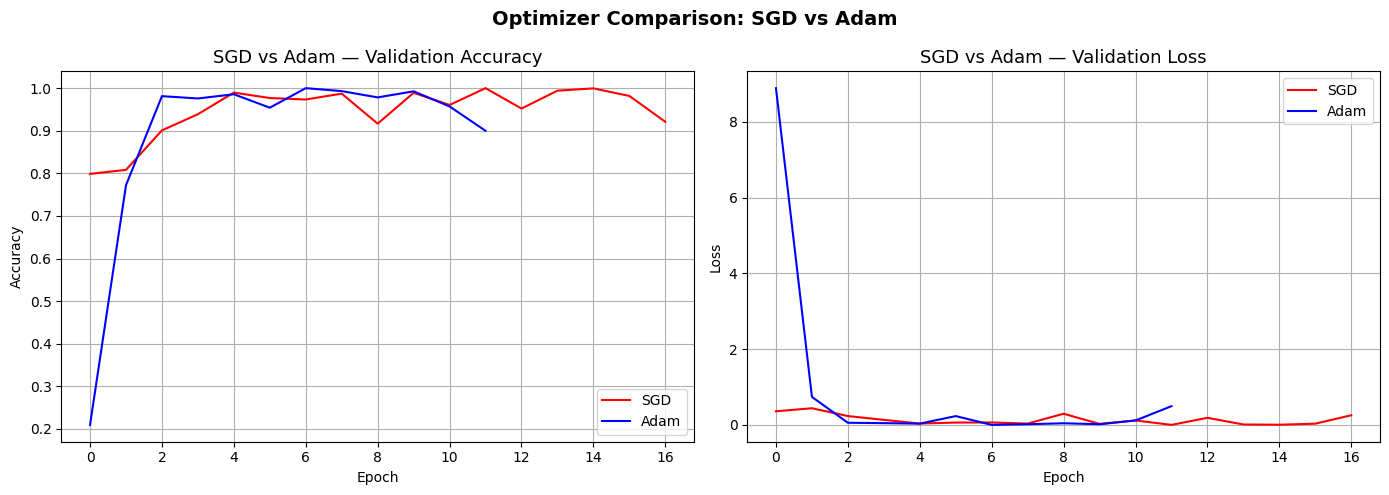

In [47]:
# ============================================================
# STEP 6C — Compare SGD vs Adam on same graph
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Validation Accuracy ---
axes[0].plot(history_sgd.history['val_accuracy'],
             label='SGD', color='red')
axes[0].plot(history_adam.history['val_accuracy'],
             label='Adam', color='blue')
axes[0].set_title('SGD vs Adam — Validation Accuracy',
                  fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# --- Validation Loss ---
axes[1].plot(history_sgd.history['val_loss'],
             label='SGD', color='red')
axes[1].plot(history_adam.history['val_loss'],
             label='Adam', color='blue')
axes[1].set_title('SGD vs Adam — Validation Loss',
                  fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('Optimizer Comparison: SGD vs Adam',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('optimizer_comparison.png', dpi=150)
plt.show()

Step 6D — Print Comparison Table

In [48]:
# ============================================================
# STEP 6D — Summary table for SGD vs Adam
# ============================================================

print('=' * 55)
print(f'{"Optimizer":<20} {"Best Val Acc":>15} {"Train Time":>15}')
print('=' * 55)
print(f'{"SGD":<20} {sgd_acc*100:>14.2f}%'
      f' {sgd_time:>13.1f}s')
print(f'{"Adam":<20} {adam_acc*100:>14.2f}%'
      f' {adam_time:>13.1f}s')
print('=' * 55)

# Automatic observation
print('\nObservation:')
if adam_acc > sgd_acc:
    print(f' Adam performed better by'
          f' {(adam_acc - sgd_acc)*100:.2f}%')
    print('Adam converges faster because it adapts the')
    print('learning rate automatically for each parameter.')
else:
    print(f' SGD performed better by'
          f' {(sgd_acc - adam_acc)*100:.2f}%')
    print('SGD with momentum generalized better on this dataset.')

print('\nTrade-off:')
print('Adam → faster training, good default choice')
print('SGD  → slower but sometimes better final accuracy')

Optimizer               Best Val Acc      Train Time
SGD                          100.00%         744.5s
Adam                         100.00%         564.7s

Observation:
 SGD performed better by 0.00%
SGD with momentum generalized better on this dataset.

Trade-off:
Adam → faster training, good default choice
SGD  → slower but sometimes better final accuracy


Step 7A — Build Model Without Dropout

In [49]:
# ============================================================
# STEP 7 — Ablation Study
#
# Ablation study means removing one component to see
# how much it contributes to the model performance
#
# Here we REMOVE Dropout to show what happens without it
# Expected result: model will OVERFIT
# (high train accuracy but low val accuracy)
# ============================================================

def build_deeper_cnn_no_dropout(num_classes,
                                input_shape=(128, 128, 3)):
    """Same as deeper CNN but WITHOUT any Dropout layers."""

    model = models.Sequential(name='No_Dropout_CNN')

    # Block 1
    model.add(layers.Conv2D(32, (3, 3), activation='relu',
                            padding='same',
                            input_shape=input_shape))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(32, (3, 3), activation='relu',
                            padding='same'))
    model.add(layers.MaxPooling2D((2, 2)))
    # NO Dropout here

    # Block 2
    model.add(layers.Conv2D(64, (3, 3), activation='relu',
                            padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(64, (3, 3), activation='relu',
                            padding='same'))
    model.add(layers.MaxPooling2D((2, 2)))
    # NO Dropout here

    # Block 3
    model.add(layers.Conv2D(128, (3, 3), activation='relu',
                            padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(128, (3, 3), activation='relu',
                            padding='same'))
    model.add(layers.MaxPooling2D((2, 2)))
    # NO Dropout here

    # Flatten
    model.add(layers.Flatten())

    # Dense layers — NO Dropout
    model.add(layers.Dense(512, activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Dense(256, activation='relu'))
    model.add(layers.Dense(128, activation='relu'))

    # Output
    model.add(layers.Dense(num_classes, activation='softmax'))

    return model


model_no_dropout = build_deeper_cnn_no_dropout(NUM_CLASSES)
model_no_dropout.summary()

Model: "No_Dropout_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_24 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 512)            │    16,777,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 20)             │         2,580 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,234,484 (65.74 MB)

 Trainable params: 17,233,012 (65.74 MB)

 Non-trainable params: 1,472 (5.75 KB)

Step 7B — Train Model Without Dropout

In [50]:
# ============================================================
# STEP 7B — Train the no-dropout model
# ============================================================

model_no_dropout.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print('Training model WITHOUT Dropout...\n')
start_time = time.time()

history_no_dropout = model_no_dropout.fit(
    train_gen,
    validation_data=val_gen,
    epochs=25,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=5,
                      restore_best_weights=True, verbose=1)
    ],
    verbose=1
)

no_dropout_time = time.time() - start_time
print(f'\n Done! Training time: {no_dropout_time:.1f} seconds')

Training model WITHOUT Dropout...

Epoch 1/25
255/255 ━━━━━━━━━━━━━━━━━━━━ 56s 185ms/step - accuracy: 0.8852 - loss: 0.3595 - val_accuracy: 0.2347 - val_loss: 5.0913
Epoch 2/25
255/255 ━━━━━━━━━━━━━━━━━━━━ 44s 171ms/step - accuracy: 0.9621 - loss: 0.1099 - val_accuracy: 0.6622 - val_loss: 1.9700
Epoch 3/25
255/255 ━━━━━━━━━━━━━━━━━━━━ 42s 166ms/step - accuracy: 0.9693 - loss: 0.0902 - val_accuracy: 0.6134 - val_loss: 4.0026
Epoch 4/25
255/255 ━━━━━━━━━━━━━━━━━━━━ 42s 165ms/step - accuracy: 0.9826 - loss: 0.0625 - val_accuracy: 0.9965 - val_loss: 0.0094
Epoch 5/25
255/255 ━━━━━━━━━━━━━━━━━━━━ 42s 165ms/step - accuracy: 0.9899 - loss: 0.0318 - val_accuracy: 1.0000 - val_loss: 3.0436e-04
Epoch 6/25
255/255 ━━━━━━━━━━━━━━━━━━━━ 42s 165ms/step - accuracy: 0.9834 - loss: 0.0526 - val_accuracy: 0.9359 - val_loss: 0.3247
Epoch 7/25
255/255 ━━━━━━━━━━━━━━━━━━━━ 44s 172ms/step - accuracy: 0.9745 - loss: 0.0898 - val_accuracy: 0.9522 - val_loss: 0.2514
Epoch 8/25
255/255 ━━━━━━━━━━━━━━━━━━━━ 43s 

Step 7C — Compare With vs Without Dropout

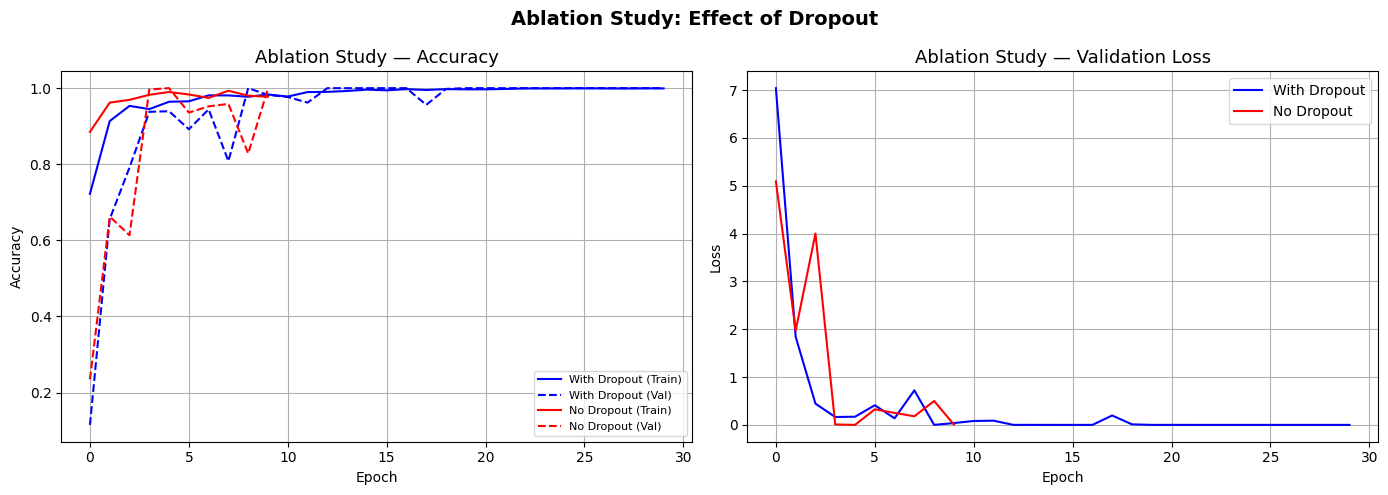

Model                             Best Val Acc
With Dropout                           100.00%
Without Dropout                        100.00%

Observation:
If No-Dropout train acc >> val acc = OVERFITTING
Dropout reduces this gap = better generalization


In [51]:
# ============================================================
# STEP 7C — Plot comparison: With Dropout vs Without Dropout
#
# Look for the GAP between train and val accuracy:
# Large gap = overfitting (no dropout)
# Small gap = good generalization (with dropout)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy comparison
axes[0].plot(history_deeper.history['accuracy'],
             label='With Dropout (Train)',
             color='blue')
axes[0].plot(history_deeper.history['val_accuracy'],
             label='With Dropout (Val)',
             color='blue', linestyle='--')
axes[0].plot(history_no_dropout.history['accuracy'],
             label='No Dropout (Train)',
             color='red')
axes[0].plot(history_no_dropout.history['val_accuracy'],
             label='No Dropout (Val)',
             color='red', linestyle='--')
axes[0].set_title('Ablation Study — Accuracy', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend(fontsize=8)
axes[0].grid(True)

# Loss comparison
axes[1].plot(history_deeper.history['val_loss'],
             label='With Dropout', color='blue')
axes[1].plot(history_no_dropout.history['val_loss'],
             label='No Dropout', color='red')
axes[1].set_title('Ablation Study — Validation Loss',
                  fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('Ablation Study: Effect of Dropout',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('ablation_study.png', dpi=150)
plt.show()

# Print summary
no_dropout_acc = max(history_no_dropout.history['val_accuracy'])
dropout_acc    = max(history_deeper.history['val_accuracy'])

print('=' * 50)
print(f'{"Model":<25} {"Best Val Acc":>20}')
print('=' * 50)
print(f'{"With Dropout":<25} {dropout_acc*100:>19.2f}%')
print(f'{"Without Dropout":<25} {no_dropout_acc*100:>19.2f}%')
print('=' * 50)
print('\nObservation:')
print('If No-Dropout train acc >> val acc = OVERFITTING')
print('Dropout reduces this gap = better generalization')

Step 8 — Show Sample Predictions

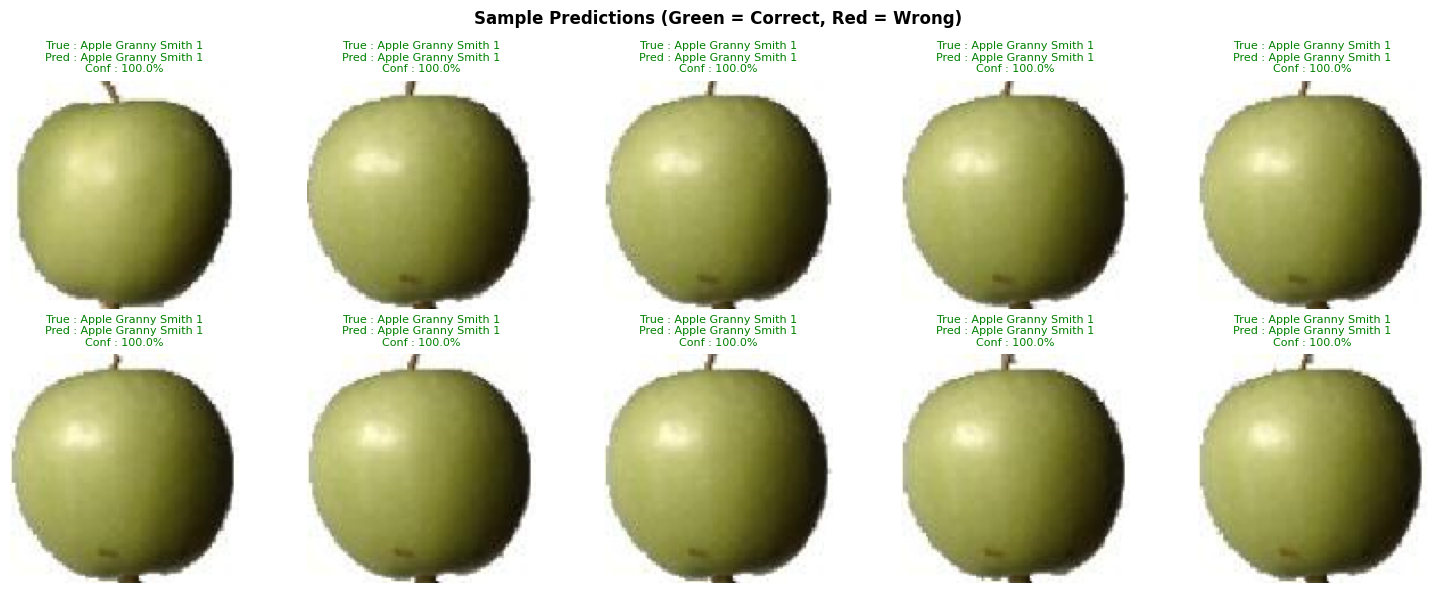

In [52]:
# ============================================================
# STEP 8 — Show sample predictions from the deeper model
#
# Green title = correct prediction
# Red title   = wrong prediction
# ============================================================

val_gen.reset()
images, labels = next(val_gen)
preds = deeper_model.predict(images, verbose=0)

plt.figure(figsize=(15, 6))
for i in range(10):
    ax = plt.subplot(2, 5, i + 1)
    plt.imshow(images[i])

    true_label  = CLASS_NAMES[np.argmax(labels[i])]
    pred_label  = CLASS_NAMES[np.argmax(preds[i])]
    confidence  = np.max(preds[i]) * 100

    # Green if correct, Red if wrong
    color = 'green' if true_label == pred_label else 'red'

    plt.title(
        f'True : {true_label}\n'
        f'Pred : {pred_label}\n'
        f'Conf : {confidence:.1f}%',
        fontsize=8, color=color
    )
    plt.axis('off')

plt.suptitle(
    'Sample Predictions (Green = Correct, Red = Wrong)',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig('sample_predictions.png', dpi=150)
plt.show()

Step 9A — Create New Generators for MobileNetV2

In [53]:
# ============================================================
# STEP 9A — Create new generators with 224x224 image size
#
# WHY 224x224?
# MobileNetV2 was originally trained on ImageNet with
# 224x224 images so we must match that input size
# ============================================================

TL_IMG_SIZE = (224, 224)  # MobileNetV2 requires 224x224

# Training generator with augmentation
tl_train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

# Validation generator — only rescale
tl_val_datagen = ImageDataGenerator(
    rescale=1.0/255,
    validation_split=0.2
)

# Training generator
tl_train_gen = tl_train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=TL_IMG_SIZE,    # 224x224 for MobileNetV2
    batch_size=32,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42
)

# Validation generator
tl_val_gen = tl_val_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=TL_IMG_SIZE,
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)

print(' Transfer learning generators created!')
print(f'Training batches  : {len(tl_train_gen)}')
print(f'Validation batches: {len(tl_val_gen)}')

Found 8143 images belonging to 20 classes.
Found 2028 images belonging to 20 classes.
 Transfer learning generators created!
Training batches  : 255
Validation batches: 64


Step 9B — Load MobileNetV2

In [54]:
# ============================================================
# STEP 9B — Load MobileNetV2 pretrained on ImageNet
#
# include_top=False → removes the original 1000 class output
# weights='imagenet' → use weights learned from 1.2M images
#
# We then ADD OUR OWN output layer for 5 fruit classes
# ============================================================

# Load MobileNetV2 base model
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,      # remove original output layer
    weights='imagenet'      # use pretrained ImageNet weights
)

# Freeze ALL layers of MobileNetV2
# This keeps the features it learned from ImageNet
base_model.trainable = False

print(f' MobileNetV2 loaded!')
print(f'Total layers in MobileNetV2 : {len(base_model.layers)}')
print(f'All layers frozen           : {not base_model.trainable}')
print('\nMobileNetV2 will act as a feature extractor')
print('We only train our custom layers on top of it')

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
 MobileNetV2 loaded!
Total layers in MobileNetV2 : 154
All layers frozen           : True

MobileNetV2 will act as a feature extractor
We only train our custom layers on top of it


Step 9C — Add Custom Layers on Top

In [55]:
# ============================================================
# STEP 9C — Build full transfer learning model
#
# Structure:
# MobileNetV2 (frozen) → GlobalAveragePooling → Dense → Output
#
# GlobalAveragePooling2D:
# Converts feature maps to a single vector
# Better than Flatten for transfer learning
# ============================================================

tl_model = models.Sequential([
    base_model,                          # pretrained feature extractor
    layers.GlobalAveragePooling2D(),     # convert to 1D vector
    layers.Dense(256, activation='relu'),# our custom dense layer
    layers.Dropout(0.3),                 # prevent overfitting
    layers.Dense(NUM_CLASSES,            # output for 5 fruit classes
                 activation='softmax')
], name='MobileNetV2_Fruit_Classifier')

tl_model.summary()

Model: "MobileNetV2_Fruit_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 20)             │         5,140 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,591,060 (9.88 MB)

 Trainable params: 333,076 (1.27 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

Step 10A — Phase 1: Feature Extraction

In [56]:
# ============================================================
# STEP 10A — Phase 1: Feature Extraction
#
# We train ONLY our custom top layers
# MobileNetV2 base is completely frozen
#
# WHY?
# MobileNetV2 already knows how to extract good features
# We just need to teach it to classify our 5 fruit classes
# ============================================================

tl_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print('Phase 1: Feature Extraction')
print('MobileNetV2 is frozen — only training top layers...\n')
start_time = time.time()

history_tl_phase1 = tl_model.fit(
    tl_train_gen,
    validation_data=tl_val_gen,
    epochs=15,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=5,
                      restore_best_weights=True, verbose=1)
    ],
    verbose=1
)

phase1_time = time.time() - start_time
phase1_acc  = max(history_tl_phase1.history['val_accuracy'])

print(f'\n Phase 1 done!')
print(f'Best Validation Accuracy : {phase1_acc*100:.2f}%')
print(f'Training Time            : {phase1_time:.1f} seconds')

Phase 1: Feature Extraction
MobileNetV2 is frozen — only training top layers...

Epoch 1/15
255/255 ━━━━━━━━━━━━━━━━━━━━ 146s 496ms/step - accuracy: 0.9229 - loss: 0.2800 - val_accuracy: 0.9724 - val_loss: 0.0893
Epoch 2/15
255/255 ━━━━━━━━━━━━━━━━━━━━ 97s 379ms/step - accuracy: 0.9944 - loss: 0.0266 - val_accuracy: 0.9724 - val_loss: 0.0882
Epoch 3/15
255/255 ━━━━━━━━━━━━━━━━━━━━ 143s 384ms/step - accuracy: 0.9966 - loss: 0.0157 - val_accuracy: 0.9749 - val_loss: 0.0711
Epoch 4/15
255/255 ━━━━━━━━━━━━━━━━━━━━ 100s 392ms/step - accuracy: 0.9973 - loss: 0.0113 - val_accuracy: 0.9951 - val_loss: 0.0264
Epoch 5/15
255/255 ━━━━━━━━━━━━━━━━━━━━ 102s 401ms/step - accuracy: 0.9978 - loss: 0.0088 - val_accuracy: 0.9714 - val_loss: 0.0868
Epoch 6/15
255/255 ━━━━━━━━━━━━━━━━━━━━ 100s 390ms/step - accuracy: 0.9962 - loss: 0.0122 - val_accuracy: 0.9906 - val_loss: 0.0307
Epoch 7/15
255/255 ━━━━━━━━━━━━━━━━━━━━ 98s 384ms/step - accuracy: 0.9969 - loss: 0.0128 - val_accuracy: 0.9773 - val_loss: 0.06

Step 10B — Phase 2: Fine Tuning

In [57]:
# ============================================================
# STEP 10B — Phase 2: Fine Tuning
#
# Now we UNFREEZE the last 30 layers of MobileNetV2
# and let them adjust to our fruit dataset
#
# WHY low learning rate (1e-5)?
# If learning rate is too high we will destroy the
# pretrained weights that MobileNetV2 already learned
# ============================================================

# Unfreeze the base model
base_model.trainable = True

# Freeze all layers EXCEPT the last 30
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Count trainable layers
trainable = sum(1 for l in base_model.layers if l.trainable)
print(f'Trainable layers in base : {trainable}')
print(f'Frozen layers in base    : '
      f'{len(base_model.layers) - trainable}')

# Recompile with very small learning rate
tl_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print('\nPhase 2: Fine Tuning')
print('Last 30 layers unfrozen — training with low LR...\n')
start_time = time.time()

history_tl_phase2 = tl_model.fit(
    tl_train_gen,
    validation_data=tl_val_gen,
    epochs=15,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=5,
                      restore_best_weights=True, verbose=1)
    ],
    verbose=1
)

phase2_time = time.time() - start_time
phase2_acc  = max(history_tl_phase2.history['val_accuracy'])
tl_total_time = phase1_time + phase2_time

print(f'\n Phase 2 done!')
print(f'Best Validation Accuracy : {phase2_acc*100:.2f}%')
print(f'Training Time            : {phase2_time:.1f} seconds')
print(f'Total TL Training Time   : {tl_total_time:.1f} seconds')

Trainable layers in base : 30
Frozen layers in base    : 124

Phase 2: Fine Tuning
Last 30 layers unfrozen — training with low LR...

Epoch 1/15
255/255 ━━━━━━━━━━━━━━━━━━━━ 133s 453ms/step - accuracy: 0.8803 - loss: 0.4224 - val_accuracy: 0.9438 - val_loss: 0.1646
Epoch 2/15
255/255 ━━━━━━━━━━━━━━━━━━━━ 100s 392ms/step - accuracy: 0.9835 - loss: 0.0627 - val_accuracy: 0.9472 - val_loss: 0.1488
Epoch 3/15
255/255 ━━━━━━━━━━━━━━━━━━━━ 101s 394ms/step - accuracy: 0.9932 - loss: 0.0312 - val_accuracy: 0.9660 - val_loss: 0.1014
Epoch 4/15
255/255 ━━━━━━━━━━━━━━━━━━━━ 100s 394ms/step - accuracy: 0.9955 - loss: 0.0215 - val_accuracy: 0.9650 - val_loss: 0.0987
Epoch 5/15
255/255 ━━━━━━━━━━━━━━━━━━━━ 101s 396ms/step - accuracy: 0.9967 - loss: 0.0165 - val_accuracy: 0.9714 - val_loss: 0.0878
Epoch 6/15
255/255 ━━━━━━━━━━━━━━━━━━━━ 100s 391ms/step - accuracy: 0.9979 - loss: 0.0101 - val_accuracy: 0.9734 - val_loss: 0.0809
Epoch 7/15
255/255 ━━━━━━━━━━━━━━━━━━━━ 102s 401ms/step - accuracy: 0.9982

Step 10C — Plot Transfer Learning History

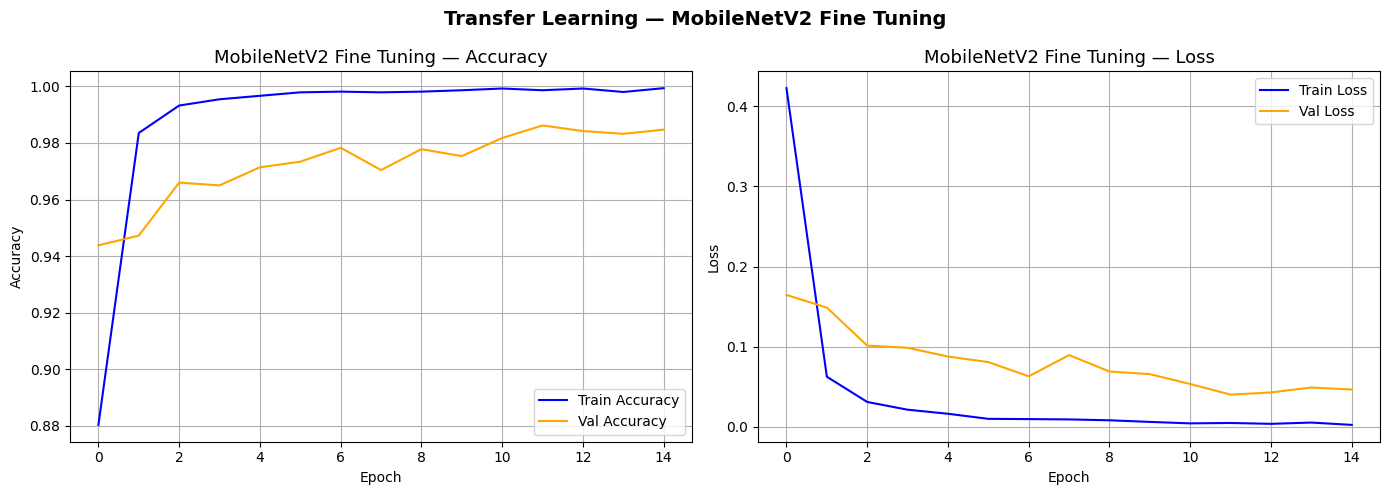

In [58]:
# ============================================================
# STEP 10C — Plot Phase 2 training curves
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history_tl_phase2.history['accuracy'],
             label='Train Accuracy', color='blue')
axes[0].plot(history_tl_phase2.history['val_accuracy'],
             label='Val Accuracy', color='orange')
axes[0].set_title('MobileNetV2 Fine Tuning — Accuracy',
                  fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# Loss
axes[1].plot(history_tl_phase2.history['loss'],
             label='Train Loss', color='blue')
axes[1].plot(history_tl_phase2.history['val_loss'],
             label='Val Loss', color='orange')
axes[1].set_title('MobileNetV2 Fine Tuning — Loss',
                  fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('Transfer Learning — MobileNetV2 Fine Tuning',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('transfer_learning_history.png', dpi=150)
plt.show()

Step 10D — Evaluate Transfer Learning Model

64/64 ━━━━━━━━━━━━━━━━━━━━ 12s 102ms/step

 MobileNetV2 Accuracy: 98.62%

Classification Report:
                      precision    recall  f1-score   support

Apple Granny Smith 1       1.00      1.00      1.00        98
         Apple Red 1       1.00      1.00      1.00        98
           Avocado 1       0.97      1.00      0.98        85
            Banana 1       1.00      1.00      1.00        98
         Blueberry 1       1.00      1.00      1.00        92
            Cherry 1       1.00      1.00      1.00        98
             Cocos 1       1.00      0.96      0.98        98
        Grape Blue 1       1.00      1.00      1.00       196
              Kiwi 1       0.91      1.00      0.95        93
             Lemon 1       1.00      1.00      1.00        98
             Mango 1       0.89      1.00      0.94        98
            Orange 1       1.00      1.00      1.00        95
            Papaya 1       1.00      0.76      0.86        98
             Peach 1       1.00   

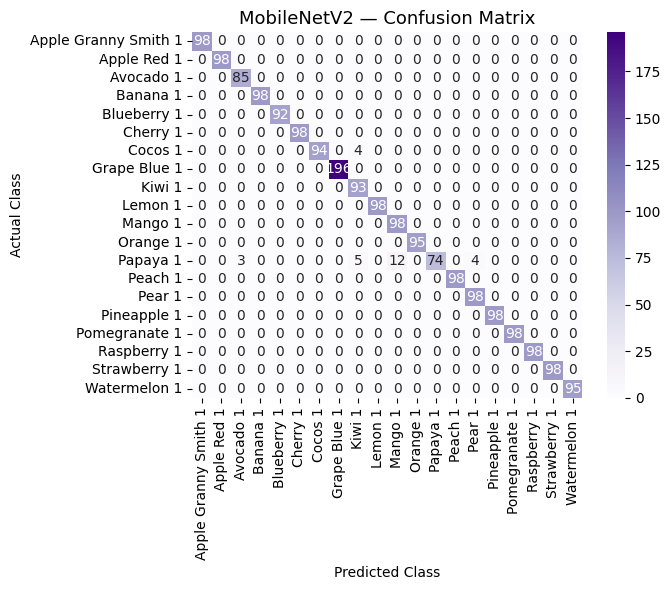

In [59]:
# ============================================================
# STEP 10D — Evaluate MobileNetV2 on validation set
# ============================================================

tl_val_gen.reset()
y_pred_tl    = tl_model.predict(tl_val_gen, verbose=1)
y_pred_tl    = np.argmax(y_pred_tl, axis=1)
y_true_tl    = tl_val_gen.classes

tl_acc = np.sum(y_pred_tl == y_true_tl) / len(y_true_tl)

print(f'\n MobileNetV2 Accuracy: {tl_acc*100:.2f}%')

# Classification report
print('\nClassification Report:')
print(classification_report(y_true_tl, y_pred_tl,
                            target_names=CLASS_NAMES))

# Confusion matrix
cm_tl = confusion_matrix(y_true_tl, y_pred_tl)
plt.figure(figsize=(7, 6))
sns.heatmap(cm_tl, annot=True, fmt='d', cmap='Purples',
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES)
plt.title('MobileNetV2 — Confusion Matrix', fontsize=13)
plt.ylabel('Actual Class')
plt.xlabel('Predicted Class')
plt.tight_layout()
plt.savefig('tl_confusion_matrix.png', dpi=150)
plt.show()

Step 11 — Final Comparison All 3 Models

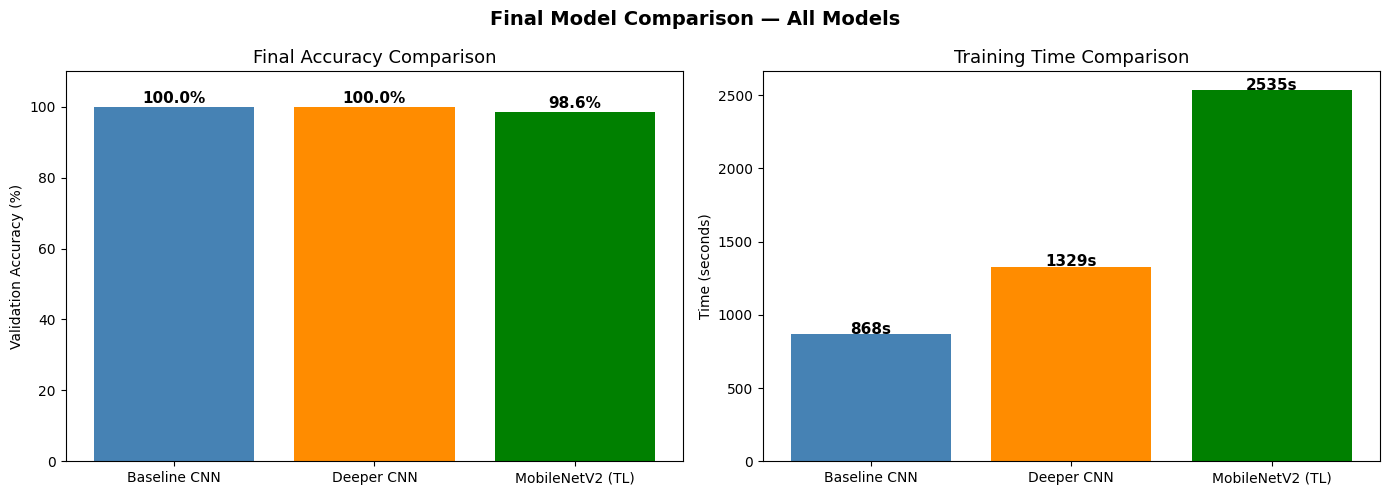

Model                         Accuracy         Train Time
Baseline CNN                   100.00%            868.2s
Deeper CNN                     100.00%           1328.7s
MobileNetV2 (TL)                98.62%           2535.0s

 Best model: Baseline CNN with 100.00% accuracy

Conclusion:
Transfer learning outperforms training from scratch
because MobileNetV2 already learned rich features
from 1.2 million ImageNet images.


In [60]:
# ============================================================
# STEP 11 — Final comparison of all 3 models
# Baseline CNN vs Deeper CNN vs MobileNetV2
# ============================================================

model_names = ['Baseline CNN', 'Deeper CNN', 'MobileNetV2 (TL)']
accuracies  = [baseline_acc * 100,
               deeper_acc * 100,
               tl_acc * 100]
train_times = [baseline_train_time,
               deeper_train_time,
               tl_total_time]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['steelblue', 'darkorange', 'green']

# Accuracy bar chart
bars1 = axes[0].bar(model_names, accuracies, color=colors)
axes[0].set_title('Final Accuracy Comparison', fontsize=13)
axes[0].set_ylabel('Validation Accuracy (%)')
axes[0].set_ylim(0, 110)
for bar, val in zip(bars1, accuracies):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 1,
        f'{val:.1f}%', ha='center',
        fontsize=11, fontweight='bold'
    )

# Training time bar chart
bars2 = axes[1].bar(model_names, train_times, color=colors)
axes[1].set_title('Training Time Comparison', fontsize=13)
axes[1].set_ylabel('Time (seconds)')
for bar, val in zip(bars2, train_times):
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 1,
        f'{val:.0f}s', ha='center',
        fontsize=11, fontweight='bold'
    )

plt.suptitle('Final Model Comparison — All Models',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('final_comparison.png', dpi=150)
plt.show()

# Final summary table
print('=' * 60)
print(f'{"Model":<22} {"Accuracy":>15} {"Train Time":>18}')
print('=' * 60)
for name, acc, t in zip(model_names, accuracies, train_times):
    print(f'{name:<22} {acc:>14.2f}% {t:>16.1f}s')
print('=' * 60)
best = model_names[np.argmax(accuracies)]
print(f'\n Best model: {best} with'
      f' {max(accuracies):.2f}% accuracy')
print('\nConclusion:')
print('Transfer learning outperforms training from scratch')
print('because MobileNetV2 already learned rich features')
print('from 1.2 million ImageNet images.')